# **Medical Text Classification and Analysis**

EDA Dataset (POS Tag, uUnigrams, NER Tag)</br>
Text Preprocessing </br>
Text Embedding </br>
Text Classification menggunakan Logistic Regression, Naive Bayes dan SVM </br>

# 0.Import Library

In [49]:
import os
import re
import nltk
import kagglehub
import spacy, math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from spacy import displacy
from spacy.tokens import Doc
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from IPython.display import HTML, display
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# 1.Load Dataset 

import dataset langsung dari kaggle menggunakan package kagglehub

In [2]:
# Download latest version
path = kagglehub.dataset_download(
    "falgunipatel19/biomedical-text-publication-classification",
    output_dir="./dataset", # direktori untuk menyimpan file unduhan dari kaggle
)

print("Path dataset:", path)

Path dataset: ./dataset


In [3]:
df = pd.read_csv("dataset/alldata_1_for_kaggle.csv", encoding="latin1")
df.head()

,Unnamed: 0,0,a
0,0,Thyroid_Cancer,Thyroid surgery in children in a single insti...
1,1,Thyroid_Cancer,""" The adopted strategy was the same as that us..."
2,2,Thyroid_Cancer,coronary arterybypass grafting thrombosis ï¬b...
3,3,Thyroid_Cancer,Solitary plasmacytoma SP of the skull is an u...
4,4,Thyroid_Cancer,This study aimed to investigate serum matrix ...


# 2.EDA Dataset

Jumlah data, distribusi data, missing values, duplicated row, panjang teks dan token

In [4]:
df.columns = ["new_col1", "Label", "Text"]
df = df.drop(columns="new_col1")
df.head()

,Label,Text
0,Thyroid_Cancer,Thyroid surgery in children in a single insti...
1,Thyroid_Cancer,""" The adopted strategy was the same as that us..."
2,Thyroid_Cancer,coronary arterybypass grafting thrombosis ï¬b...
3,Thyroid_Cancer,Solitary plasmacytoma SP of the skull is an u...
4,Thyroid_Cancer,This study aimed to investigate serum matrix ...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7570 entries, 0 to 7569
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Label   7570 non-null   str  
 1   Text    7570 non-null   str  
dtypes: str(2)
memory usage: 118.4 KB


In [6]:
df.shape

(7570, 2)

In [7]:
# Check missing value
missing = pd.DataFrame({
    "Missing Values":  df.isna().sum(),
    "Percentage (%)": (df.isna().sum() / len(df) * 100).round(2)
})

missing

,Missing Values,Percentage (%)
Label,0,0.0
Text,0,0.0


In [8]:
# Check duplicate row
print("Duplicated Row: ", df.duplicated().sum())

Duplicated Row:  6574


In [9]:
# Cleaning duplicated rows
df = df.drop_duplicates()
print("Duplicated Row: ", df.duplicated().sum())

Duplicated Row:  0


C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\3322126413.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts, palette="flare")


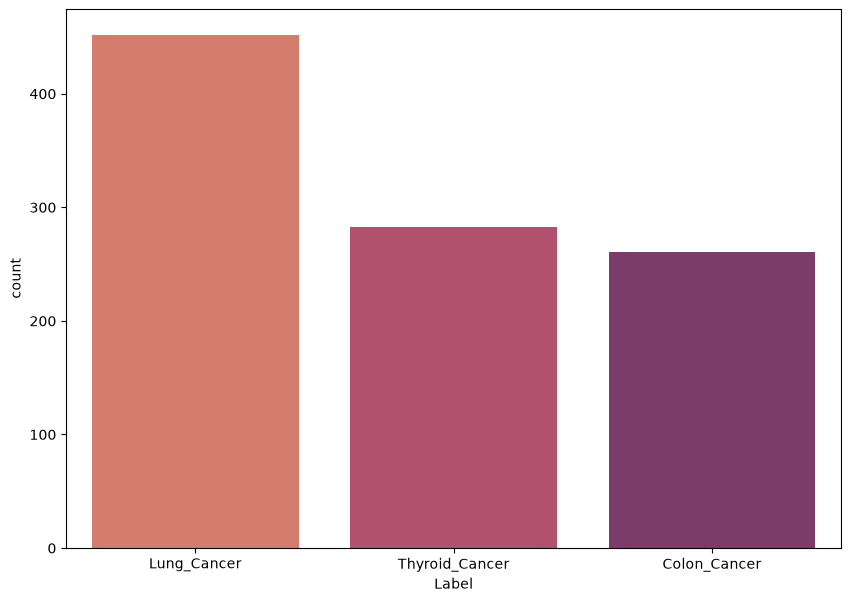

In [10]:
# Mevisualisasikan jumlah data per Label
label_counts = df["Label"].value_counts()
label_counts

plt.figure(figsize=(10, 7))
sns.barplot(x=label_counts.index, y=label_counts, palette="flare")
plt.show()

In [11]:
df["Text_len"] = df["Text"].str.len()
df["Word_Count"] = df["Text"].apply(lambda x: len(str(x).split()))

In [12]:
df.head()

,Label,Text,Text_len,Word_Count
0,Thyroid_Cancer,Thyroid surgery in children in a single insti...,20707,2871
1,Thyroid_Cancer,""" The adopted strategy was the same as that us...",17018,2494
2,Thyroid_Cancer,coronary arterybypass grafting thrombosis ï¬b...,21622,2954
3,Thyroid_Cancer,Solitary plasmacytoma SP of the skull is an u...,13860,1880
4,Thyroid_Cancer,This study aimed to investigate serum matrix ...,23696,3037


In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 996 entries, 0 to 7497
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Label       996 non-null    str  
 1   Text        996 non-null    str  
 2   Text_len    996 non-null    int64
 3   Word_Count  996 non-null    int64
dtypes: int64(2), str(2)
memory usage: 38.9 KB


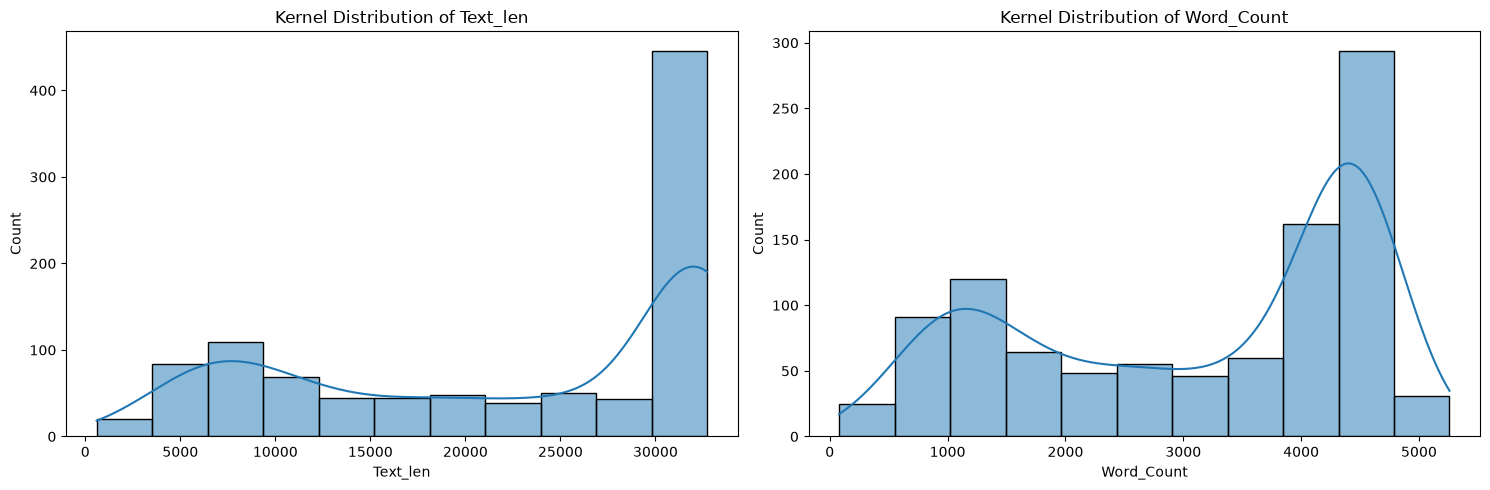

In [14]:
num_cols = df.select_dtypes(include="number").columns

n_cols = len(num_cols)
n_rows = math.ceil(n_cols / 2)

fig, ax = plt.subplots(n_rows, 2, figsize=(15, 5 * n_rows))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    axes = sns.histplot(data=df[col], kde=True, ax=ax[i])
    axes.set(title="Kernel Distribution of {}".format(col))

for i in range(n_cols, len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.show()

C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\1229942965.py:11: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Thyroid_Cancer, shade=True, color="red").set_title("Kernel distribution of number of word")
C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\1229942965.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Colon_Cancer, shade=True, color="blue")
C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\1229942965.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Lung_Cancer, shade=True, color="green")


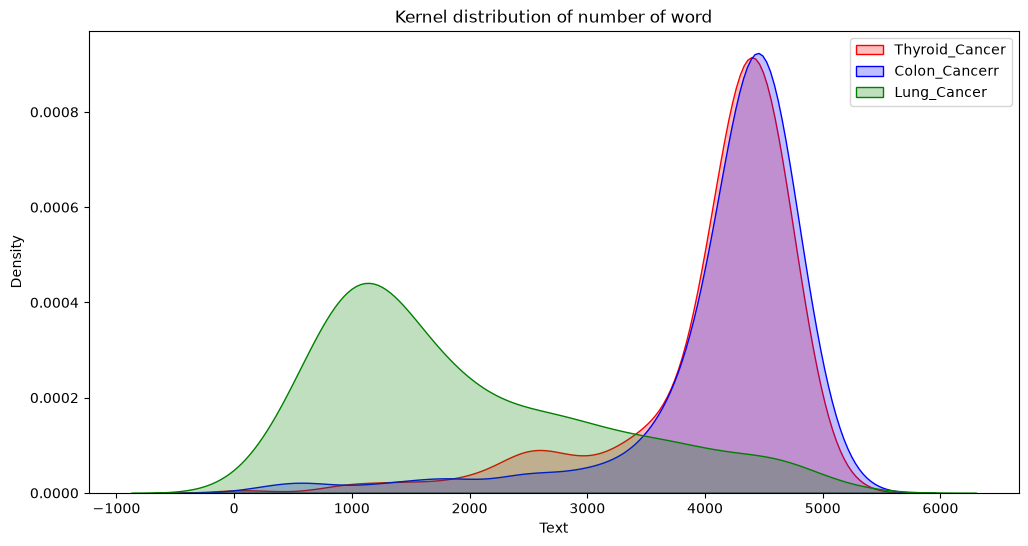

In [15]:
plt.figure(figsize=(12, 6))
# Menghitung jumlah kata dalam kategori Thyroid_Cancer
Thyroid_Cancer = df[df["Label"] == "Thyroid_Cancer"]["Text"].apply(lambda x: len(x.split()))  

# Menghitung jumlah kata dalam kategori Colon_Cancer
Colon_Cancer = df[df["Label"] == "Colon_Cancer"]["Text"].apply(lambda x: len(x.split()))  

# Menghitung jumlah kata dalam kategori Lung_Cancer
Lung_Cancer = df[df["Label"] == "Lung_Cancer"]["Text"].apply(lambda x: len(x.split()))  

sns.kdeplot(Thyroid_Cancer, shade=True, color="red").set_title("Kernel distribution of number of word")
sns.kdeplot(Colon_Cancer, shade=True, color="blue")
sns.kdeplot(Lung_Cancer, shade=True, color="green")
plt.legend(labels=["Thyroid_Cancer", "Colon_Cancerr", "Lung_Cancer"])
plt.show()

# 3.Data Preprocessing

In [16]:
en_stopwords = stopwords.words("english")
en_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [17]:
def clean_one(text: str) -> str:
    text = re.sub(r"^[^-]*-\s", "", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"\bRT\b", " ", text)
    text = text.lower()
    text = re.sub(r"[0-9]+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    return " ".join(w for w in text.split() if w not in (en_stopwords))


def cleaning_text(df):
    df["Text_Clean"] = df["Text"].apply(clean_one)
    df["Token"] = df["Text_Clean"].apply(word_tokenize)
    return df

In [18]:
cleaning_text(df)

,Label,Text,Text_len,Word_Count,Text_Clean,Token
0,Thyroid_Cancer,Thyroid surgery in children in a single insti...,20707,2871,thyroid surgery children single institution os...,"[thyroid, surgery, children, single, instituti..."
1,Thyroid_Cancer,""" The adopted strategy was the same as that us...",17018,2494,adopted strategy used prior years based four e...,"[adopted, strategy, used, prior, years, based,..."
2,Thyroid_Cancer,coronary arterybypass grafting thrombosis ï¬b...,21622,2954,coronary arterybypass grafting thrombosis ï br...,"[coronary, arterybypass, grafting, thrombosis,..."
3,Thyroid_Cancer,Solitary plasmacytoma SP of the skull is an u...,13860,1880,solitary plasmacytoma sp skull uncommon clinic...,"[solitary, plasmacytoma, sp, skull, uncommon, ..."
4,Thyroid_Cancer,This study aimed to investigate serum matrix ...,23696,3037,study aimed investigate serum matrix metallopr...,"[study, aimed, investigate, serum, matrix, met..."
...,...,...,...,...,...,...
6863,Lung_Cancer,"""Missense mutation distribution in the exons a...",11284,1713,missense mutation distribution exons functiona...,"[missense, mutation, distribution, exons, func..."
6929,Lung_Cancer,"""versus gemcitabine/carboplatin in advanced no...",20333,3016,versus gemcitabine carboplatin advanced non sm...,"[versus, gemcitabine, carboplatin, advanced, n..."
7040,Thyroid_Cancer,Keloids are pathological scars that grow over...,32449,4219,keloids pathological scars grow time extend be...,"[keloids, pathological, scars, grow, time, ext..."
7485,Colon_Cancer,the anization of cells into multiple membranou...,32212,4128,anization cells multiple membranous compartmen...,"[anization, cells, multiple, membranous, compa..."


In [19]:
tokens_raw_list = sum(df["Token"], [])
tokens_raw_list

['thyroid',
 'surgery',
 'children',
 'single',
 'institution',
 'osama',
 'ibrahim',
 'almosallama',
 'ali',
 'aseerib',
 'ahmed',
 'alhumaida',
 'ali',
 'alzahranic',
 'saif',
 'alsobhib',
 'saud',
 'alshanafeybfrom',
 'adepartment',
 'surgery',
 'college',
 'medicine',
 'qassim',
 'university',
 'buraidah',
 'al',
 'qassim',
 'saudi',
 'arabia',
 'bdepartment',
 'surgery',
 'king',
 'faisal',
 'specialist',
 'hospital',
 'research',
 'center',
 'riyadh',
 'saudi',
 'arabia',
 'cdepartment',
 'medicine',
 'king',
 'faisal',
 'specialist',
 'hospital',
 'research',
 'center',
 'riyadh',
 'saudi',
 'arabia',
 'correspondence',
 'dr',
 'osama',
 'ibrahim',
 'almosallam',
 'department',
 'surgery',
 'college',
 'medicine',
 'qassim',
 'university',
 'po',
 'box',
 'buraidah',
 'al',
 'qassim',
 'saudi',
 'arabia',
 'osama_iaahotmailcom',
 'orcid',
 'orcid',
 'citation',
 'almosallam',
 'oi',
 'aseeri',
 'alhumaid',
 'alzahrani',
 'alsobhi',
 'alshanafey',
 'thyroid',
 'surgery',
 'childr

In [20]:
nlp = spacy.load("en_core_web_sm")

chunk_size = 50_000
rows = []

for i in range(0, len(tokens_raw_list), chunk_size):
    words = tokens_raw_list[i:i + chunk_size]
    docs = Doc(nlp.vocab, words=words)
    for name, proc in nlp.pipeline:
        docs = proc(docs)
    rows.extend((t.text, t.pos_) for t in docs)

pos_df = pd.DataFrame(rows, columns=["token", "pos_tag"])
pos_df

,token,pos_tag
0,thyroid,NOUN
1,surgery,NOUN
2,children,NOUN
3,single,ADJ
4,institution,NOUN
...,...,...
2113956,johnson,PROPN
2113957,la,PROPN
2113958,heemskerk,PROPN
2113959,b,PROPN


In [21]:
pos_df_counts = pos_df.groupby(["token", "pos_tag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)
pos_df_counts

,token,pos_tag,counts
28695,cancer,NOUN,17732
32724,cells,NOUN,15065
136619,patients,NOUN,14142
32463,cell,NOUN,10933
64582,expression,NOUN,9627
...,...,...,...
206252,ïhypo,PROPN,1
206247,ï,PART,1
16,_ampdlbcl_myd,PROPN,1
15,_ampdlbcl_,PROPN,1


Text(0.5, 1.0, 'Top 10 Pos_tag in Document')

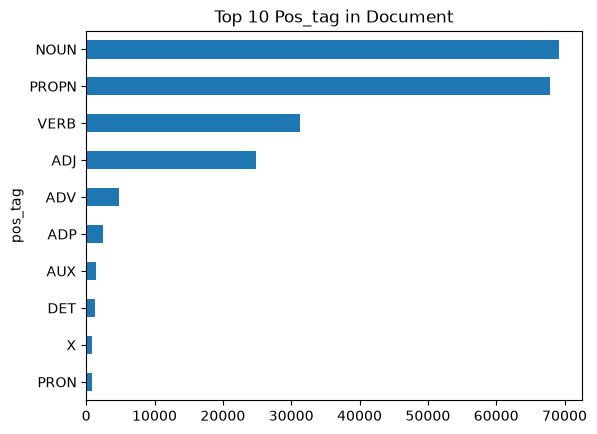

In [22]:
pos_df_counts["pos_tag"].value_counts().head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Pos_tag in Document")

In [23]:
pos_df_poscounts = pd.DataFrame(pos_df_counts.groupby(["pos_tag"])["token"].count().sort_values(ascending=False))
pos_df_poscounts

,token
pos_tag,
NOUN,69122
PROPN,67812
VERB,31232
ADJ,24865
ADV,4773
ADP,2418
AUX,1371
DET,1329
X,919


C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\2454317055.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axes = sns.barplot(data=pos_df_counts[pos_df_counts.pos_tag == cols][:10], x="counts", y="token", palette="flare", ax=ax[i])
C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\2454317055.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axes = sns.barplot(data=pos_df_counts[pos_df_counts.pos_tag == cols][:10], x="counts", y="token", palette="flare", ax=ax[i])
C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\2454317055.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue`

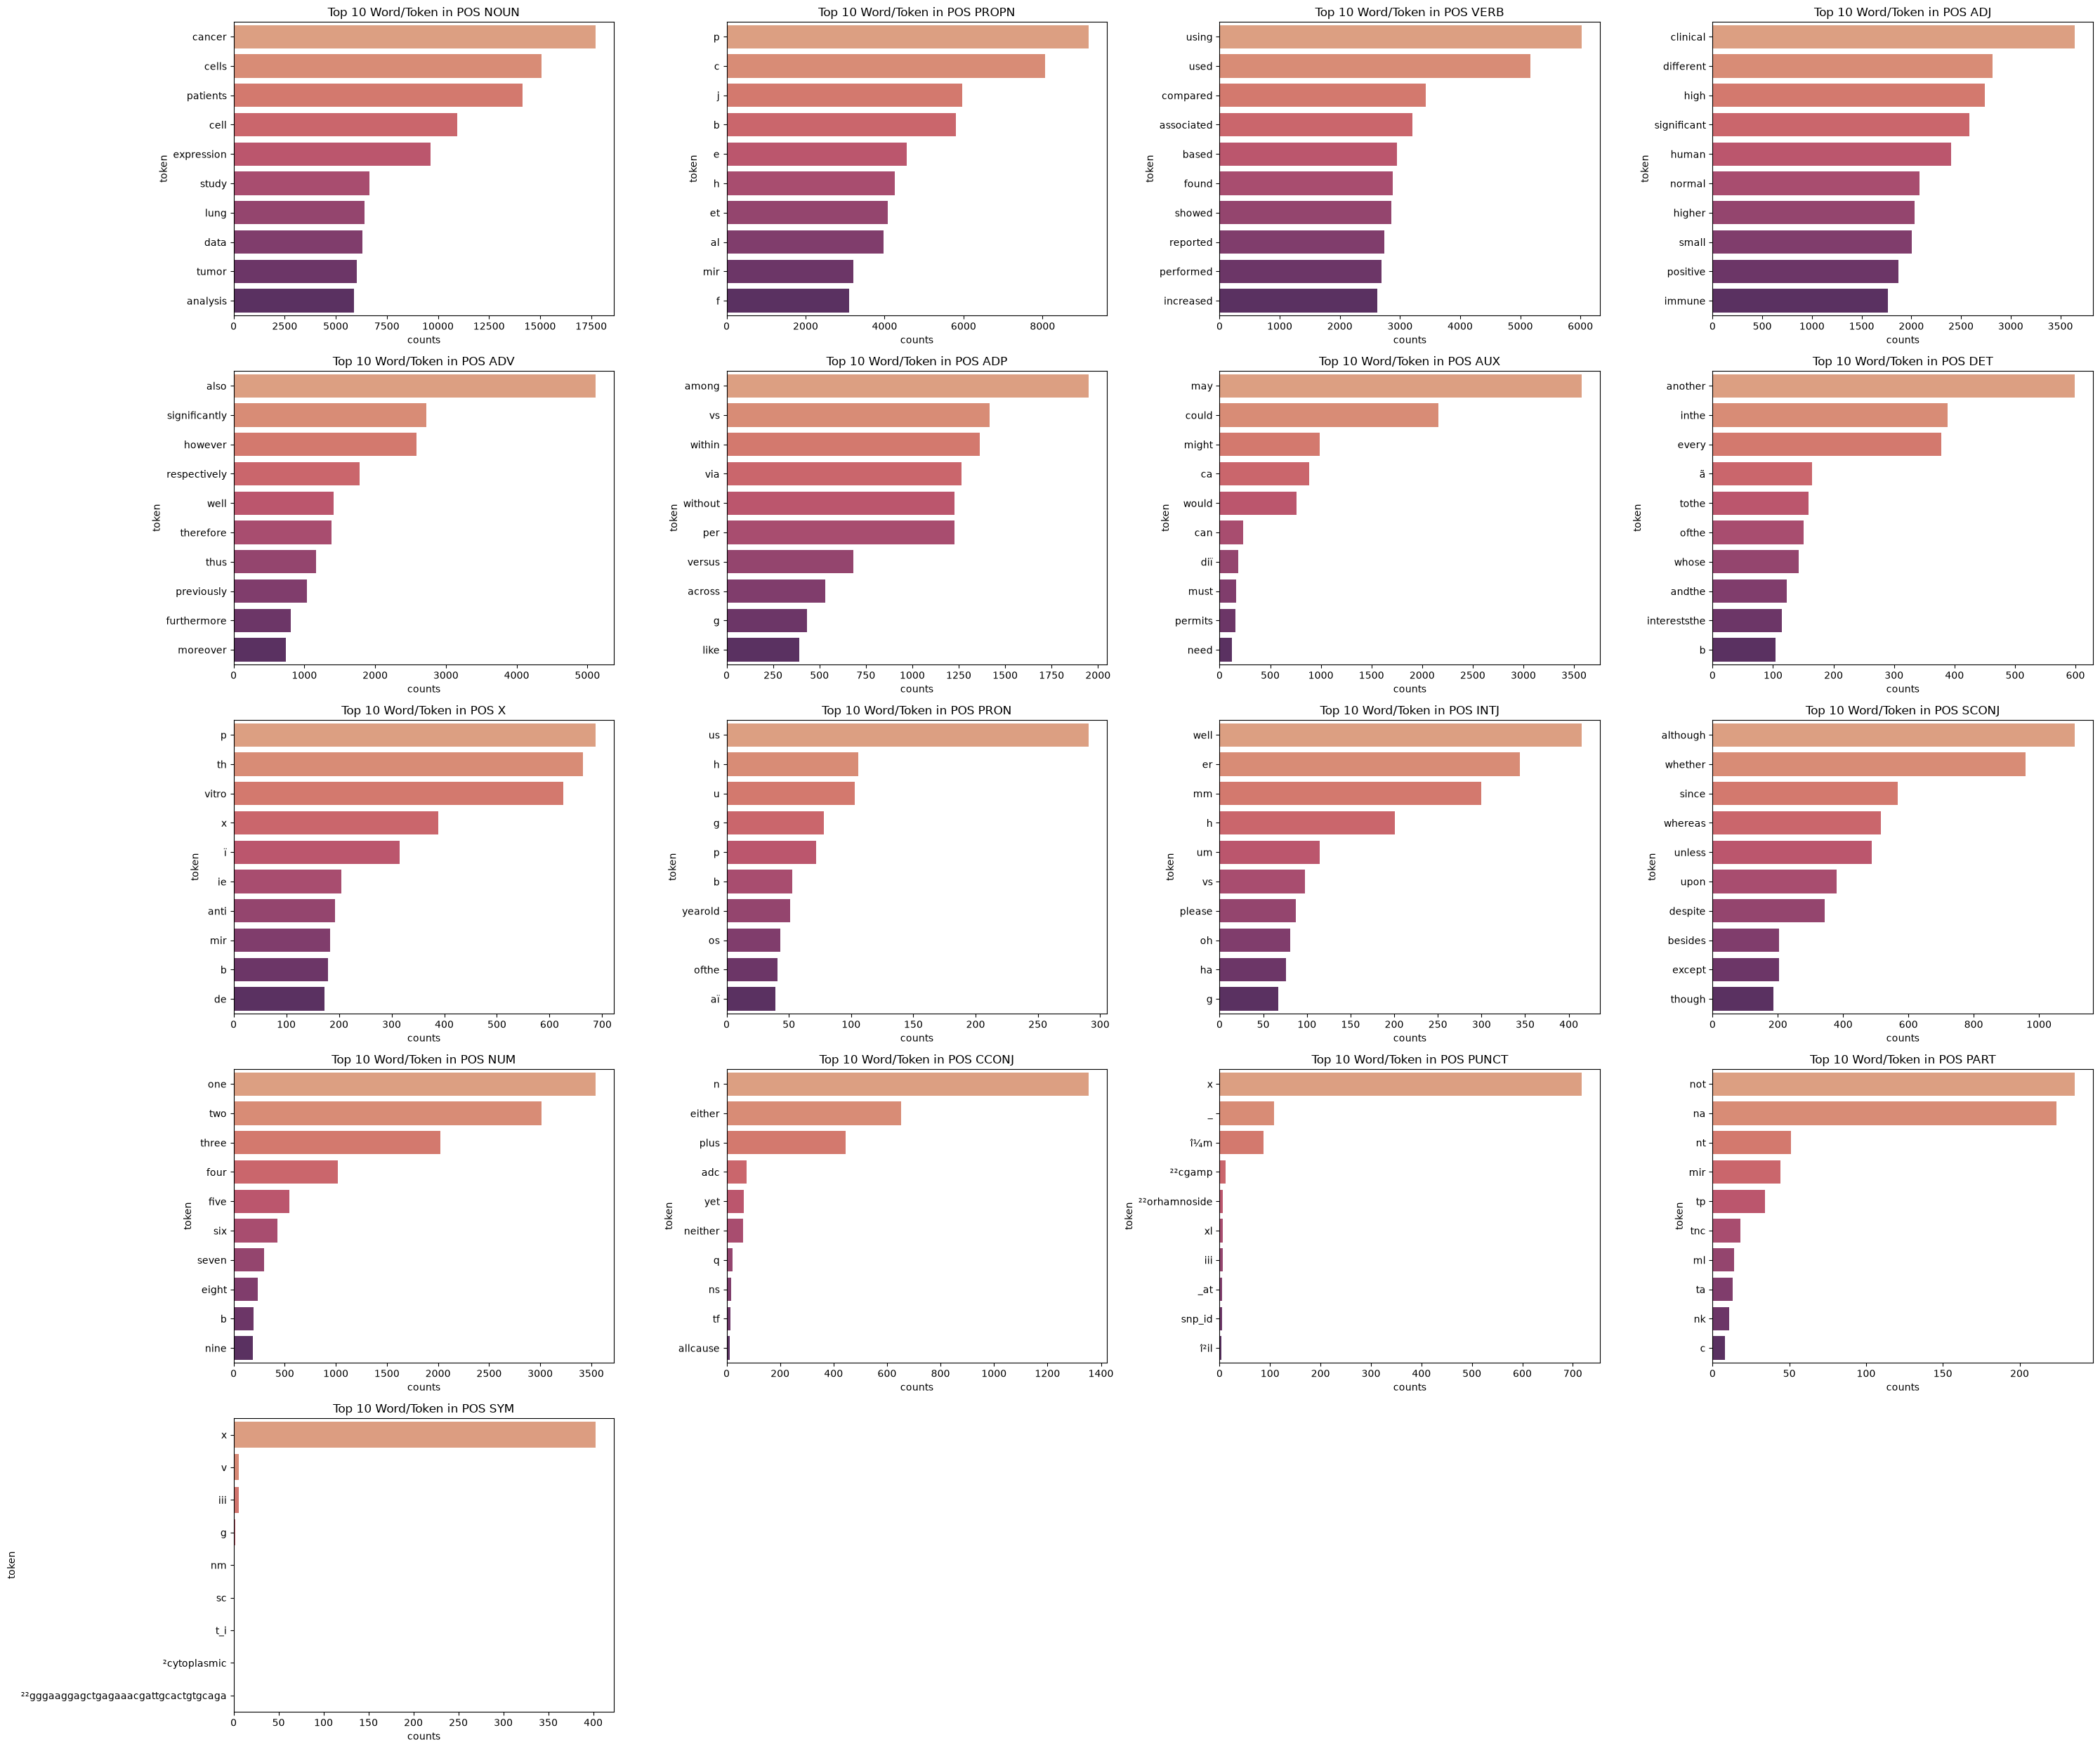

In [24]:
# Menampilkan 10 token terbanyak dari masing-masing pos tag

n_cols_pos = len(pos_df_poscounts)
n_rows_pos = math.ceil(n_cols_pos / 4)

fig, ax = plt.subplots(n_rows_pos, 4, figsize=(30, 5 * n_rows_pos))
ax = ax.flatten()

for i, cols in enumerate(pos_df_poscounts.index):
    axes = sns.barplot(data=pos_df_counts[pos_df_counts.pos_tag == cols][:10], x="counts", y="token", palette="flare", ax=ax[i])
    axes.set(title="Top 10 Word/Token in POS {}".format(cols))

for i in range(n_cols_pos, len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.show()

In [25]:
ner_tag = pd.DataFrame(columns=["token", "ner_tag"])

rows = []
for i in range(0, len(tokens_raw_list), chunk_size):
    words = tokens_raw_list[i:i + chunk_size]
    docs = Doc(nlp.vocab, words=words)
    for name, proc in nlp.pipeline:
        docs = proc(docs)
    rows.extend((e.text, e.label_) for e in docs.ents)

ner_df = pd.DataFrame(rows, columns=["token", "ner_tag"])
ner_df

,token,ner_tag
0,ibrahim almosallama,PERSON
1,ali aseerib,PERSON
2,ali alzahranic,PERSON
3,al qassim saudi arabia,PERSON
4,faisal specialist hospital research center riyadh,ORG
...,...,...
92849,laheru da jaï,ORG
92850,nrc tran e robbins,PERSON
92851,hanada ki wang,PERSON
92852,ahmadzadeh wunderlich jr rosenbergsa,FAC


In [26]:
ner_df_counts = ner_df.groupby(["token", "ner_tag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)
ner_df_counts

,token,ner_tag,counts
30819,two,CARDINAL,2789
23680,one,CARDINAL,2527
9103,fig,ORG,1948
30139,three,CARDINAL,1831
9878,first,ORDINAL,1673
...,...,...,...
34323,î¼mpore,NORP,1
34324,î¼mpsoralidin î¼mmyricetin î¼mscutellarein î¼m...,ORG,1
34325,î¼pccchangeï,ORG,1
34326,ï rst week,DATE,1


Text(0.5, 1.0, 'Top 10 Entity in Documents')

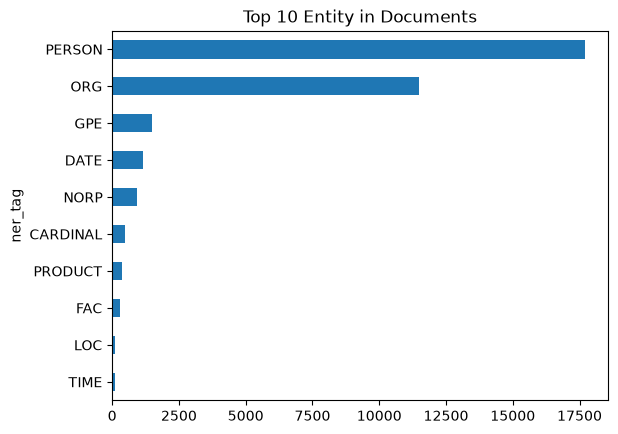

In [27]:
ner_df_counts["ner_tag"].value_counts().head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Entity in Documents")

In [28]:
ner_df_nercounts = pd.DataFrame(ner_df_counts.groupby(["ner_tag"])["token"].count().sort_values(ascending=False))
ner_df_nercounts

,token
ner_tag,
PERSON,17687
ORG,11499
GPE,1497
DATE,1166
NORP,924
CARDINAL,498
PRODUCT,356
FAC,283
LOC,124


C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\164238886.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axes = sns.barplot(data=ner_df_counts[ner_df_counts.ner_tag == cols][:10], x="counts", y="token", ax=ax[i], palette="flare")
C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\164238886.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  axes = sns.barplot(data=ner_df_counts[ner_df_counts.ner_tag == cols][:10], x="counts", y="token", ax=ax[i], palette="flare")
C:\Users\Febryo Fibonacci A\AppData\Local\Temp\ipykernel_17248\164238886.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` an

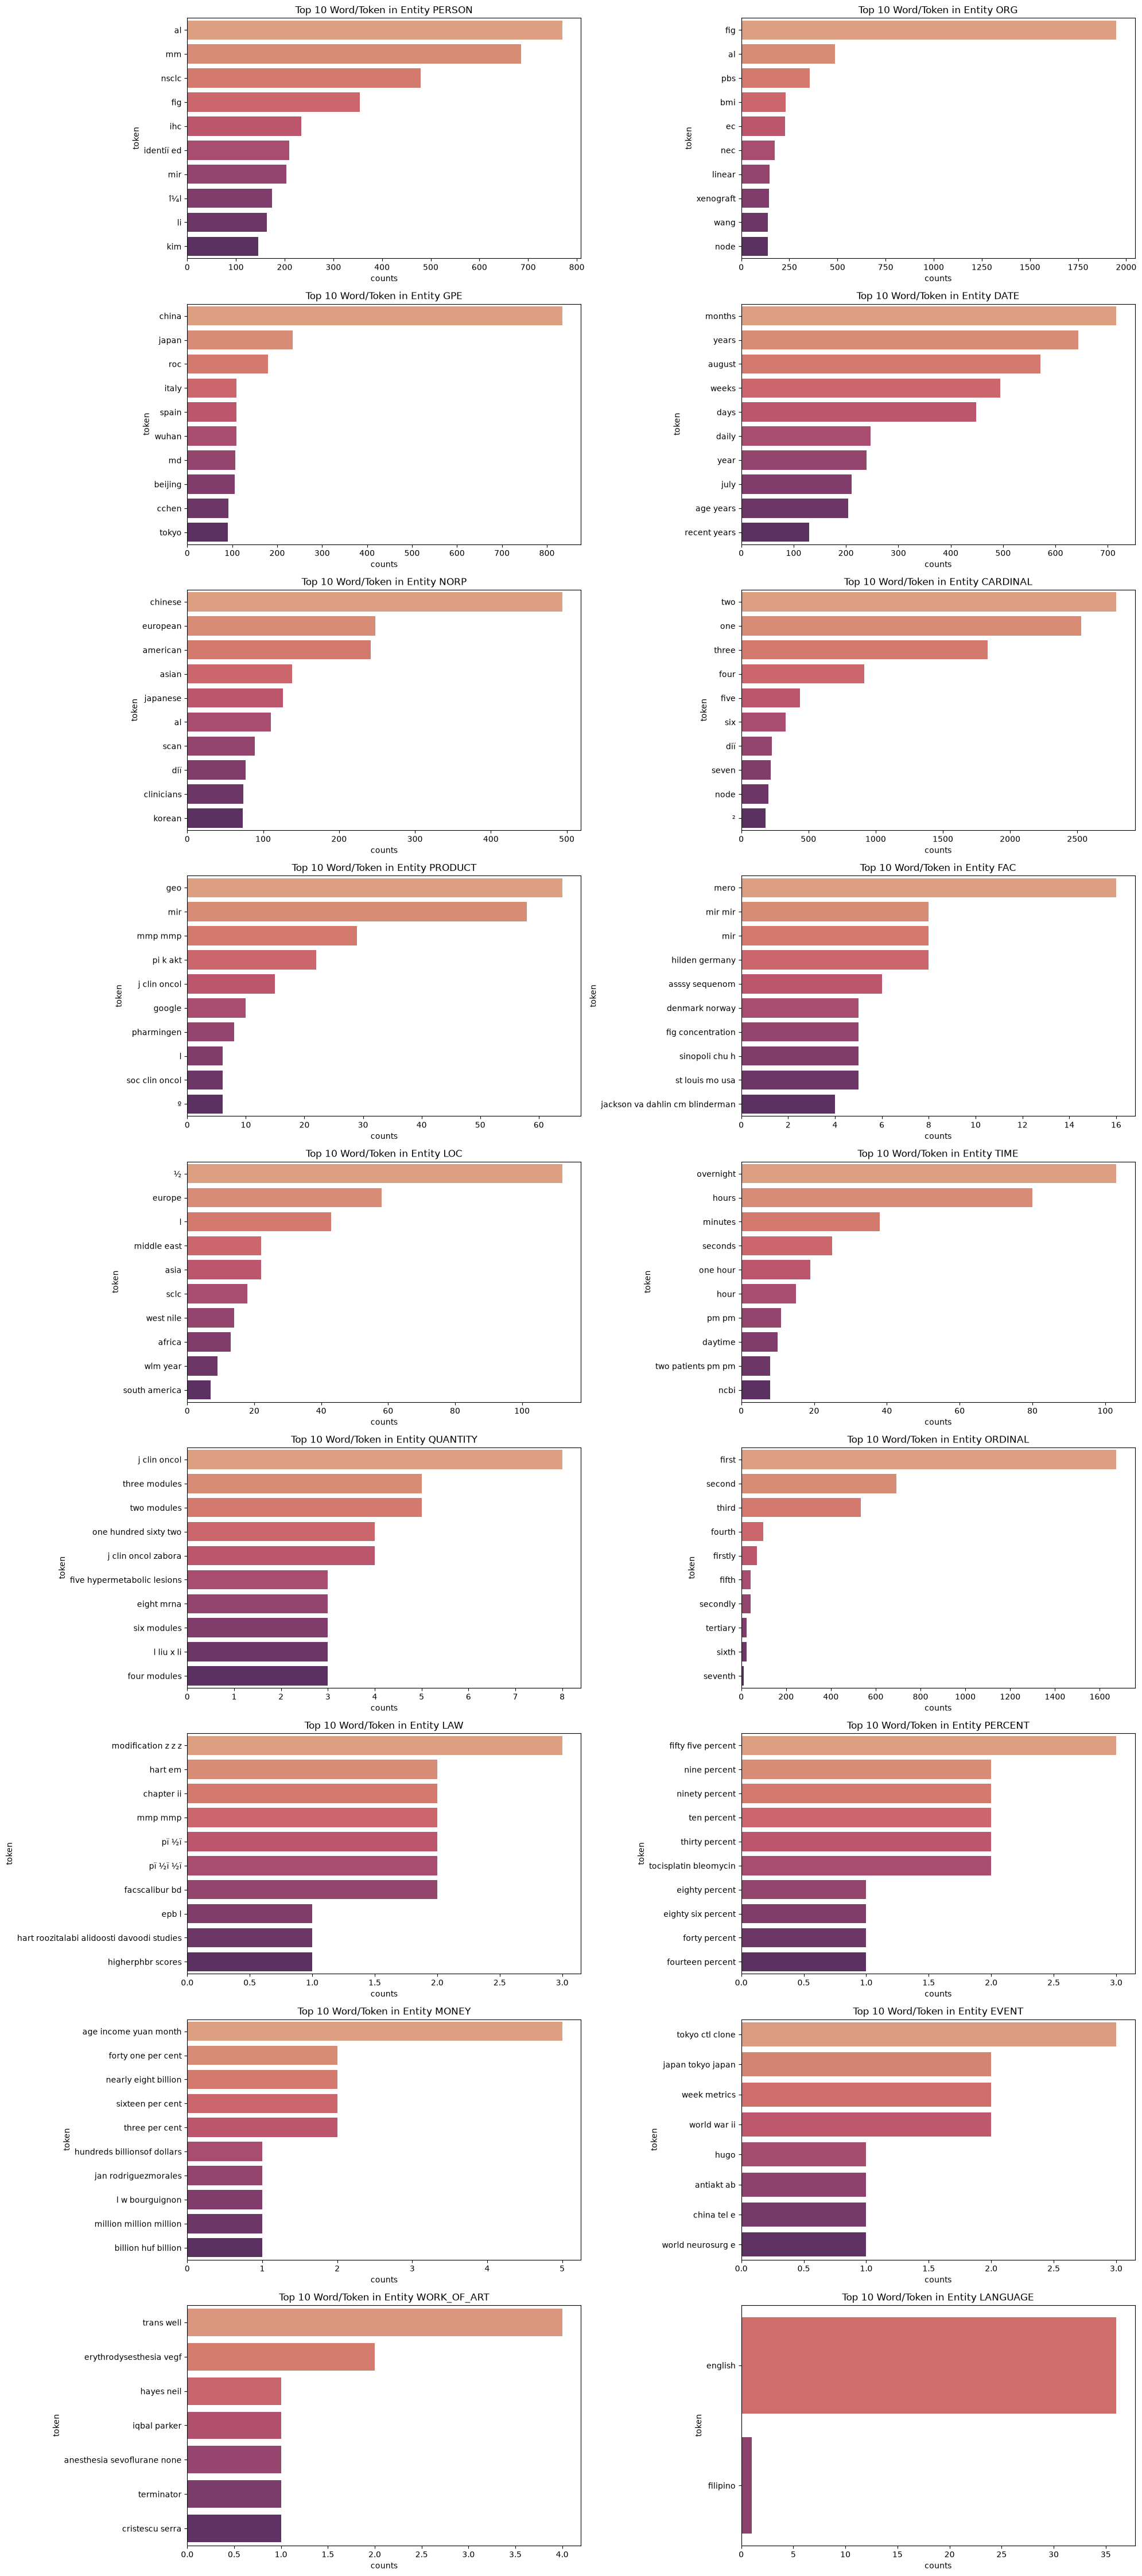

In [29]:
# Menampilkan 10 Entity 

n_cols_ner = len(ner_df_nercounts)
n_rows_ner = math.ceil(n_cols_ner / 2)

fig, ax = plt.subplots(n_rows_ner, 2, figsize=(20, 5 * n_rows_ner))
ax = ax.flatten()

for i, cols in enumerate(ner_df_nercounts.index):
    axes = sns.barplot(data=ner_df_counts[ner_df_counts.ner_tag == cols][:10], x="counts", y="token", ax=ax[i], palette="flare")
    axes.set(title="Top 10 Word/Token in Entity {}".format(cols))

for i in range(n_cols_ner, len(ax)):
    fig.delaxes(ax[i])

plt.tight_layout()
plt.show()

In [30]:
html = displacy.render(docs, style="ent", jupyter=False)
display(HTML(html))

In [31]:
# lemmatize
lemmatizer = WordNetLemmatizer()
df["lemmatized"] = df["Token"].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])
df

,Label,Text,Text_len,Word_Count,Text_Clean,Token,lemmatized
0,Thyroid_Cancer,Thyroid surgery in children in a single insti...,20707,2871,thyroid surgery children single institution os...,"[thyroid, surgery, children, single, instituti...","[thyroid, surgery, child, single, institution,..."
1,Thyroid_Cancer,""" The adopted strategy was the same as that us...",17018,2494,adopted strategy used prior years based four e...,"[adopted, strategy, used, prior, years, based,...","[adopted, strategy, used, prior, year, based, ..."
2,Thyroid_Cancer,coronary arterybypass grafting thrombosis ï¬b...,21622,2954,coronary arterybypass grafting thrombosis ï br...,"[coronary, arterybypass, grafting, thrombosis,...","[coronary, arterybypass, grafting, thrombosis,..."
3,Thyroid_Cancer,Solitary plasmacytoma SP of the skull is an u...,13860,1880,solitary plasmacytoma sp skull uncommon clinic...,"[solitary, plasmacytoma, sp, skull, uncommon, ...","[solitary, plasmacytoma, sp, skull, uncommon, ..."
4,Thyroid_Cancer,This study aimed to investigate serum matrix ...,23696,3037,study aimed investigate serum matrix metallopr...,"[study, aimed, investigate, serum, matrix, met...","[study, aimed, investigate, serum, matrix, met..."
...,...,...,...,...,...,...,...
6863,Lung_Cancer,"""Missense mutation distribution in the exons a...",11284,1713,missense mutation distribution exons functiona...,"[missense, mutation, distribution, exons, func...","[missense, mutation, distribution, exon, funct..."
6929,Lung_Cancer,"""versus gemcitabine/carboplatin in advanced no...",20333,3016,versus gemcitabine carboplatin advanced non sm...,"[versus, gemcitabine, carboplatin, advanced, n...","[versus, gemcitabine, carboplatin, advanced, n..."
7040,Thyroid_Cancer,Keloids are pathological scars that grow over...,32449,4219,keloids pathological scars grow time extend be...,"[keloids, pathological, scars, grow, time, ext...","[keloid, pathological, scar, grow, time, exten..."
7485,Colon_Cancer,the anization of cells into multiple membranou...,32212,4128,anization cells multiple membranous compartmen...,"[anization, cells, multiple, membranous, compa...","[anization, cell, multiple, membranous, compar..."


In [32]:
# N-grams
tokens_clean_list = sum(df["lemmatized"], [])
tokens_clean_list

['thyroid',
 'surgery',
 'child',
 'single',
 'institution',
 'osama',
 'ibrahim',
 'almosallama',
 'ali',
 'aseerib',
 'ahmed',
 'alhumaida',
 'ali',
 'alzahranic',
 'saif',
 'alsobhib',
 'saud',
 'alshanafeybfrom',
 'adepartment',
 'surgery',
 'college',
 'medicine',
 'qassim',
 'university',
 'buraidah',
 'al',
 'qassim',
 'saudi',
 'arabia',
 'bdepartment',
 'surgery',
 'king',
 'faisal',
 'specialist',
 'hospital',
 'research',
 'center',
 'riyadh',
 'saudi',
 'arabia',
 'cdepartment',
 'medicine',
 'king',
 'faisal',
 'specialist',
 'hospital',
 'research',
 'center',
 'riyadh',
 'saudi',
 'arabia',
 'correspondence',
 'dr',
 'osama',
 'ibrahim',
 'almosallam',
 'department',
 'surgery',
 'college',
 'medicine',
 'qassim',
 'university',
 'po',
 'box',
 'buraidah',
 'al',
 'qassim',
 'saudi',
 'arabia',
 'osama_iaahotmailcom',
 'orcid',
 'orcid',
 'citation',
 'almosallam',
 'oi',
 'aseeri',
 'alhumaid',
 'alzahrani',
 'alsobhi',
 'alshanafey',
 'thyroid',
 'surgery',
 'child',
 

In [33]:
unigrams = pd.Series(nltk.ngrams(tokens_clean_list, 1)).value_counts()
bigrams = pd.Series(nltk.ngrams(tokens_clean_list, 2)).value_counts()
trigrams = pd.Series(nltk.ngrams(tokens_clean_list, 3)).value_counts()

Text(0.5, 1.0, 'Top 10 Unigrams in Document')

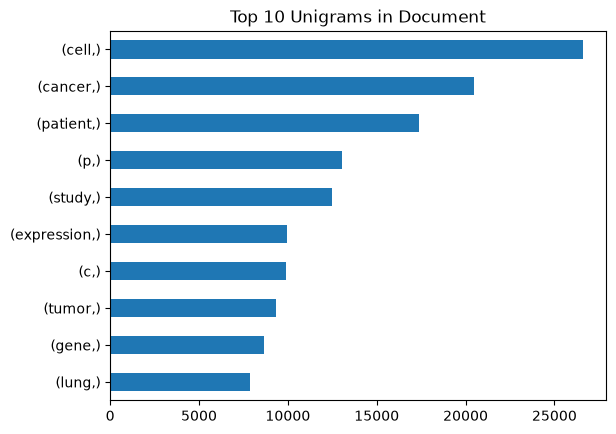

In [34]:
unigrams.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Unigrams in Document")

Text(0.5, 1.0, 'Top 10 Bigrams in Document')

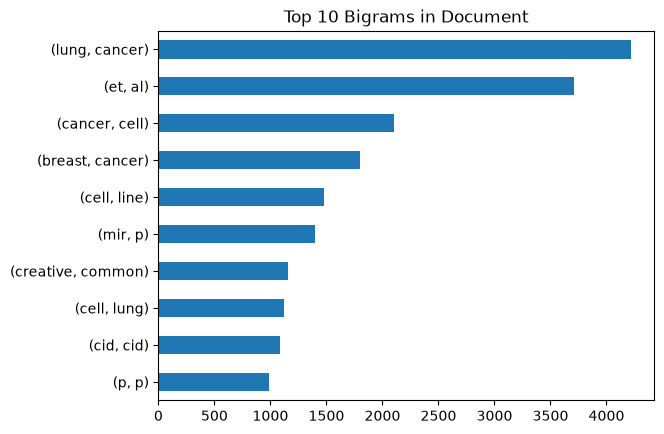

In [35]:
bigrams.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Bigrams in Document")

Text(0.5, 1.0, 'Top 10 Trigrams in Document')

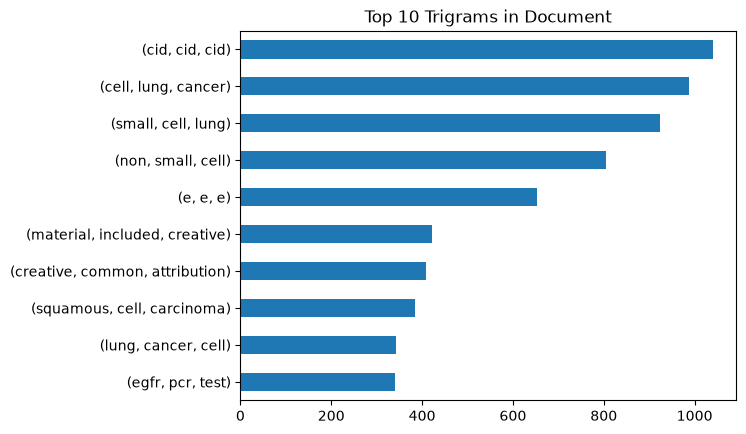

In [36]:
trigrams.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Trigrams in Document")

# 4.Feature Engineering

In [37]:
df

,Label,Text,Text_len,Word_Count,Text_Clean,Token,lemmatized
0,Thyroid_Cancer,Thyroid surgery in children in a single insti...,20707,2871,thyroid surgery children single institution os...,"[thyroid, surgery, children, single, instituti...","[thyroid, surgery, child, single, institution,..."
1,Thyroid_Cancer,""" The adopted strategy was the same as that us...",17018,2494,adopted strategy used prior years based four e...,"[adopted, strategy, used, prior, years, based,...","[adopted, strategy, used, prior, year, based, ..."
2,Thyroid_Cancer,coronary arterybypass grafting thrombosis ï¬b...,21622,2954,coronary arterybypass grafting thrombosis ï br...,"[coronary, arterybypass, grafting, thrombosis,...","[coronary, arterybypass, grafting, thrombosis,..."
3,Thyroid_Cancer,Solitary plasmacytoma SP of the skull is an u...,13860,1880,solitary plasmacytoma sp skull uncommon clinic...,"[solitary, plasmacytoma, sp, skull, uncommon, ...","[solitary, plasmacytoma, sp, skull, uncommon, ..."
4,Thyroid_Cancer,This study aimed to investigate serum matrix ...,23696,3037,study aimed investigate serum matrix metallopr...,"[study, aimed, investigate, serum, matrix, met...","[study, aimed, investigate, serum, matrix, met..."
...,...,...,...,...,...,...,...
6863,Lung_Cancer,"""Missense mutation distribution in the exons a...",11284,1713,missense mutation distribution exons functiona...,"[missense, mutation, distribution, exons, func...","[missense, mutation, distribution, exon, funct..."
6929,Lung_Cancer,"""versus gemcitabine/carboplatin in advanced no...",20333,3016,versus gemcitabine carboplatin advanced non sm...,"[versus, gemcitabine, carboplatin, advanced, n...","[versus, gemcitabine, carboplatin, advanced, n..."
7040,Thyroid_Cancer,Keloids are pathological scars that grow over...,32449,4219,keloids pathological scars grow time extend be...,"[keloids, pathological, scars, grow, time, ext...","[keloid, pathological, scar, grow, time, exten..."
7485,Colon_Cancer,the anization of cells into multiple membranou...,32212,4128,anization cells multiple membranous compartmen...,"[anization, cells, multiple, membranous, compa...","[anization, cell, multiple, membranous, compar..."


In [38]:
train_size = int(len(df) * 0.8)

df = df.sample(frac=1)

X = df["Token"].apply(" ".join)
y = df["Label"]

In [43]:
X_train, X_test, y_train, y_test = X[:train_size], X[train_size:], y[:train_size], y[train_size:]

In [44]:
tfidfvec = TfidfVectorizer()
X_train_tfidf = tfidfvec.fit_transform(X_train)
X_test_tfidf = tfidfvec.transform(X_test) 

In [45]:
X_train_tfidf = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidfvec.get_feature_names_out())
X_train_tfidf

,___,___leafxrd,_a,_amp,_ampadditional,_ampdlbcl_,_ampdlbcl_myd,_ampharbored,_amppdl,_amppmbclpatientsage,...,î¼mxrd,î¼s,î¼umle,î¾,î¾i,îî,ïkcalmol,ï¼,ï¾,ïï
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.007255,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
793,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
794,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000


In [47]:
X_test_tfidf = pd.DataFrame(X_test_tfidf.toarray(), columns=tfidfvec.get_feature_names_out())
X_test_tfidf

,___,___leafxrd,_a,_amp,_ampadditional,_ampdlbcl_,_ampdlbcl_myd,_ampharbored,_amppdl,_amppmbclpatientsage,...,î¼mxrd,î¼s,î¼umle,î¾,î¾i,îî,ïkcalmol,ï¼,ï¾,ïï
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
197,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
198,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [58]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_train_encoded

array([1, 1, 2, 2, 2, 1, 0, 1, 0, 2, 2, 0, 2, 2, 2, 0, 2, 0, 0, 1, 2, 1,
       1, 1, 0, 1, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 0, 1, 2, 1, 0, 0, 2, 1,
       2, 1, 1, 0, 1, 2, 1, 0, 1, 0, 2, 0, 1, 2, 1, 1, 1, 2, 0, 1, 2, 2,
       1, 2, 1, 2, 0, 2, 1, 1, 2, 0, 1, 2, 1, 1, 1, 2, 0, 0, 1, 1, 2, 0,
       2, 1, 2, 0, 0, 1, 2, 1, 0, 1, 0, 1, 0, 2, 1, 1, 2, 1, 2, 0, 1, 0,
       1, 1, 2, 0, 2, 2, 1, 0, 0, 0, 2, 2, 1, 0, 2, 2, 0, 1, 2, 1, 1, 2,
       2, 1, 0, 1, 2, 2, 0, 1, 2, 1, 2, 1, 0, 0, 1, 2, 1, 1, 1, 0, 2, 2,
       2, 0, 1, 1, 2, 0, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 2, 1, 0, 0, 1, 1,
       2, 1, 0, 1, 0, 1, 1, 1, 2, 2, 1, 2, 1, 1, 2, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 2, 0, 0, 2, 2, 2, 1, 2, 2, 1, 2, 2, 0, 0, 2, 1, 2,
       1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 0, 1, 2, 2, 1, 1, 2, 2, 2, 0, 2, 1,
       1, 1, 2, 2, 0, 1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 0, 0, 1, 2, 1, 2,
       0, 0, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 0, 0, 0,
       1, 1, 2, 0, 2, 1, 1, 1, 1, 0, 0, 1, 2, 2, 2,

In [59]:
y_test_encoded = encoder.transform(y_test)
y_test_encoded

array([1, 2, 0, 0, 2, 2, 1, 2, 1, 0, 1, 2, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 2, 2, 2, 1, 1, 0, 0, 2, 1, 0, 1, 2, 1, 1, 2, 1, 0, 1, 1, 1,
       1, 2, 1, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 1, 2, 1, 2, 0, 0, 1, 2, 1,
       0, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2, 1, 1, 0, 0, 0, 1, 2, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 2, 1, 1, 2, 0, 2, 1, 1, 2, 1, 1, 1,
       1, 0, 0, 1, 2, 0, 1, 0, 2, 1, 1, 0, 2, 1, 2, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 1, 2, 2, 2, 0, 2, 1, 2, 2, 1, 0, 1, 0, 1, 1, 0, 0, 2, 2,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 2, 1, 1, 1, 2, 1, 1,
       2, 1, 2, 2, 0, 1, 1, 2, 1, 1, 0, 0, 0, 1, 1, 1, 2, 2, 0, 1, 2, 1,
       1, 0])

# 5.Modeling

In [62]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

lr = LogisticRegression()
svm = SGDClassifier()
rf = RandomForestClassifier()
boosting = AdaBoostClassifier()

In [67]:
lr.fit(X_train_tfidf, y_train_encoded)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [68]:
svm.fit(X_train_tfidf, y_train_encoded)

,"<a class=""param-doc-link"" style=""anchor-name: --doc-link-loss;"" rel=""noreferrer"" target=""_blank"" href=""https://scikit-learn.org/1.9/modules/generated/sklearn.linear_model.SGDClassifier.html#:~:text=loss,-%7B%27hinge%27%2C%20%27log_loss%27%2C%20%27modified_huber%27%2C%20%27squared_hinge%27%2C%20%20%20%20%20%20%20%20%27perceptron%27%2C%20%27squared_error%27%2C%20%27huber%27%2C%20%27epsilon_insensitive%27%2C%20%20%20%20%20%20%20%20%27squared_epsilon_insensitive%27%7D%2C%20default%3D%27hinge%27""> loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide<sgd_mathematical_formulation>` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if th

In [69]:
rf.fit(X_train_tfidf, y_train_encoded)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [70]:
boosting.fit(X_train_tfidf, y_train_encoded)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](3,)","[0,1,2]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.4 ,0.35,0.42,...,0.54,0.53,0.54]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[1.09,1.29,1.03,...,0.54,0.56,0.54]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1808070885), DecisionTreeC...te=2067767422), DecisionTreeC...te=1462593167), DecisionTreeC...te=1343248447), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](145383,)","[0.,0.,0.,...,0.,0.,0.]"


In [71]:
accuracy = pd.DataFrame(columns=["Train", "Test"], index=["LogisticRegression", "SupportVectorMachine", "RandomForest", "Boosting"])
accuracy

,Train,Test
LogisticRegression,NaN,NaN
SupportVectorMachine,NaN,NaN
RandomForest,NaN,NaN
Boosting,NaN,NaN


In [72]:
model_dict = {
    "LogisticsRegression": lr, 
    "SupportVectorMachine": svm,
    "RandomForest": rf,
    "boosting": boosting     
}

model_dict

{'LogisticsRegression': LogisticRegression(),
 'SupportVectorMachine': SGDClassifier(),
 'RandomForest': RandomForestClassifier(),
 'boosting': AdaBoostClassifier()}

# 6.Result

In [73]:
from sklearn.metrics import accuracy_score

result = [
    [
        accuracy_score(y_train_encoded, model.predict(X_train_tfidf)),
        accuracy_score(y_test_encoded, model.predict(X_test_tfidf))
    ]
    for name, model in model_dict.items()
]

accuracy.loc[:, ["Train", "Test"]] = result

In [75]:
accuracy

,Train,Test
LogisticRegression,0.967337,0.78
SupportVectorMachine,0.971106,0.78
RandomForest,1.0,0.81
Boosting,0.943467,0.895


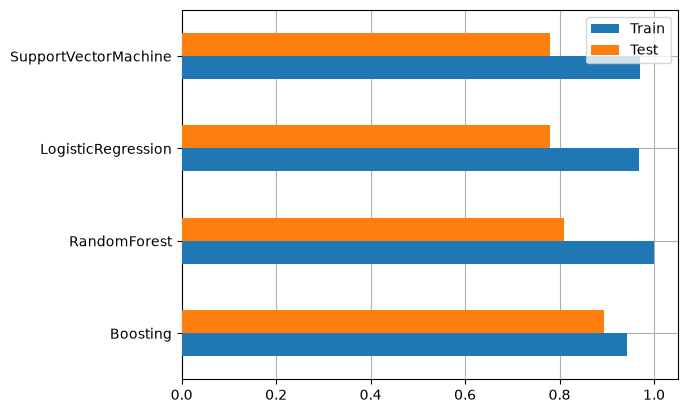

In [74]:
fig, ax = plt.subplots()
accuracy.sort_values(by="Test", ascending=False).plot(kind="barh", ax=ax, zorder=3)
ax.grid(zorder=0)

# 7.Save Model

In [76]:
import joblib

os.makedirs("models", exist_ok=True)

for name, model in model_dict.items():
    joblib.dump(model, f"models/{name}.pkl")

In [77]:
joblib.dump(tfidfvec, "models/tfidf_vectorizer.pkl")
joblib.dump(encoder, "models/label_encoder.pkl")

['models/label_encoder.pkl']